In [1]:
# ===============================
# PHASE 3 - MODEL TRAINING & EVALUATION
# Health Risk Prediction / Heart Disease Dataset
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("clean_heart_disease_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())


Dataset shape: (920, 14)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope  num  
0  lv hypertrophy   150.0  False      2.3  downsloping    0  
1  lv hypertrophy   108.0   True      1.5         flat    2  
2  lv hypertrophy   129.0   True      2.6         flat    1  
3          normal   187.0  False      3.5  downsloping    0  
4  lv hypertrophy   172.0  False      1.4    upsloping    0  

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'num']


In [3]:
# ===============================
# 2. PREPARE TARGET
# ===============================
# Convert target to binary:
# 0 = no disease, >0 = disease
df["target"] = (df["num"] > 0).astype(int)

# Drop old target and id if not needed
X = df.drop(columns=["num", "target", "id"], errors="ignore")
y = df["target"]

print("\nTarget distribution:")
print(y.value_counts())



Target distribution:
target
1    509
0    411
Name: count, dtype: int64


In [4]:
# ===============================
# 3. IDENTIFY COLUMN TYPES
# ===============================
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)



Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope']
Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


In [5]:
# ===============================
# 4. PREPROCESSING
# ===============================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


In [28]:
# ===============================
# 5. TRAIN / VALIDATION / TEST SPLIT
# ===============================
# Split data into training (80%) and a temporary set (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2, # 20% for temporary set
    random_state=42,
    stratify=y
)

# Split the temporary set into validation (50% of temp, i.e., 10% of total)
# and test (50% of temp, i.e., 10% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, # 50% of temporary set for test
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (736, 12)
Validation shape: (92, 12)
Test shape: (92, 12)


In [7]:
# ===============================
# 6. DEFINE MODELS
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    print("\nXGBoost added successfully.")
except:
    print("\nXGBoost is not installed. Gradient Boosting will be enough.")


XGBoost added successfully.


In [8]:
# ===============================
# 7. 5-FOLD CROSS-VALIDATION
# ===============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in models.items():
    print(f"\nRunning CV for {model_name}...")

    # Naive Bayes يحتاج data dense بعد one-hot
    if model_name == "Naive Bayes":
        preprocessor_nb = ColumnTransformer(transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), categorical_cols)
        ])

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor_nb),
            ("classifier", model)
        ])
    else:
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV AUC": scores["test_roc_auc"].mean()
    })

    cv_results_df = pd.DataFrame(cv_results).sort_values(by=["CV F1", "CV AUC"], ascending=False)
print("\n===== CROSS-VALIDATION RESULTS =====")
print(cv_results_df)




Running CV for Logistic Regression...

Running CV for Decision Tree...

Running CV for Random Forest...

Running CV for SVM...

Running CV for KNN...

Running CV for Naive Bayes...

Running CV for Gradient Boosting...

Running CV for XGBoost...

===== CROSS-VALIDATION RESULTS =====
                 Model  CV Accuracy  CV Precision  CV Recall     CV F1  \
3                  SVM     0.817935      0.815724   0.872147  0.841969   
0  Logistic Regression     0.808439      0.825062   0.835260  0.828461   
7              XGBoost     0.801646      0.805745   0.850045  0.826336   
2        Random Forest     0.792131      0.799067   0.840139  0.817547   
5          Naive Bayes     0.802988      0.843245   0.793466  0.816347   
6    Gradient Boosting     0.790789      0.801791   0.830413  0.814627   
4                  KNN     0.783977      0.783345   0.847546  0.813049   
1        Decision Tree     0.713265      0.750727   0.727160  0.737846   

     CV AUC  
3  0.883319  
0  0.888143  
7  0.86

In [9]:
# ===============================
# 8. VALIDATION SET EVALUATION
# ===============================
validation_results = []
trained_pipelines = {}

for model_name, model in models.items():
    print(f"\nTraining and evaluating {model_name} on validation set...")

    if model_name == "Naive Bayes":
        preprocessor_nb = ColumnTransformer(transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), categorical_cols)
        ])

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor_nb),
            ("classifier", model)
        ])
    else:
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline

    y_pred = pipeline.predict(X_val)

    # probabilities for AUC / ROC
    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_val)[:, 1]
    else:
        # fallback for models like SVM if needed
        y_proba = pipeline.decision_function(X_val)

    validation_results.append({
        "Model": model_name,
        "Validation Accuracy": accuracy_score(y_val, y_pred),
        "Validation Precision": precision_score(y_val, y_pred),
        "Validation Recall": recall_score(y_val, y_pred),
        "Validation F1": f1_score(y_val, y_pred),
        "Validation AUC": roc_auc_score(y_val, y_proba)
    })

validation_results_df = pd.DataFrame(validation_results).sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
)

print("\n===== VALIDATION RESULTS =====")
print(validation_results_df)


Training and evaluating Logistic Regression on validation set...

Training and evaluating Decision Tree on validation set...

Training and evaluating Random Forest on validation set...

Training and evaluating SVM on validation set...

Training and evaluating KNN on validation set...

Training and evaluating Naive Bayes on validation set...

Training and evaluating Gradient Boosting on validation set...

Training and evaluating XGBoost on validation set...

===== VALIDATION RESULTS =====
                 Model  Validation Accuracy  Validation Precision  \
3                  SVM             0.836957              0.815789   
5          Naive Bayes             0.847826              0.877551   
2        Random Forest             0.836957              0.839623   
7              XGBoost             0.831522              0.819820   
0  Logistic Regression             0.826087              0.818182   
4                  KNN             0.826087              0.818182   
6    Gradient Boosting 

In [10]:
# ===============================
# 9. COMBINED COMPARISON TABLE
# ===============================
comparison_df = pd.merge(cv_results_df, validation_results_df, on="Model")
comparison_df = comparison_df.sort_values(by=["Validation F1", "Validation AUC"], ascending=False)

print("\n===== FINAL COMPARISON =====")
print(comparison_df)

# Save results
cv_results_df.to_csv("cv_results.csv", index=False)
validation_results_df.to_csv("validation_results.csv", index=False)
comparison_df.to_csv("final_model_comparison.csv", index=False)



===== FINAL COMPARISON =====
                 Model  CV Accuracy  CV Precision  CV Recall     CV F1  \
0                  SVM     0.817935      0.815724   0.872147  0.841969   
4          Naive Bayes     0.802988      0.843245   0.793466  0.816347   
3        Random Forest     0.792131      0.799067   0.840139  0.817547   
2              XGBoost     0.801646      0.805745   0.850045  0.826336   
1  Logistic Regression     0.808439      0.825062   0.835260  0.828461   
6                  KNN     0.783977      0.783345   0.847546  0.813049   
5    Gradient Boosting     0.790789      0.801791   0.830413  0.814627   
7        Decision Tree     0.713265      0.750727   0.727160  0.737846   

     CV AUC  Validation Accuracy  Validation Precision  Validation Recall  \
0  0.883319             0.836957              0.815789           0.911765   
4  0.879428             0.847826              0.877551           0.843137   
3  0.868678             0.836957              0.839623           0.87254

In [11]:
# ===============================
# 10. SELECT BEST 2-3 MODELS
# ===============================
best_models = comparison_df.sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
).head(3)

print("\n===== BEST MODELS =====")
print(best_models[["Model", "Validation F1", "Validation AUC"]])


===== BEST MODELS =====
           Model  Validation F1  Validation AUC
0            SVM       0.861111        0.911406
4    Naive Bayes       0.860000        0.915710
3  Random Forest       0.855769        0.919895


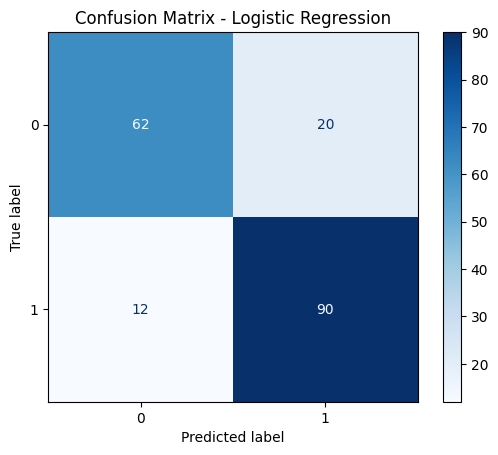

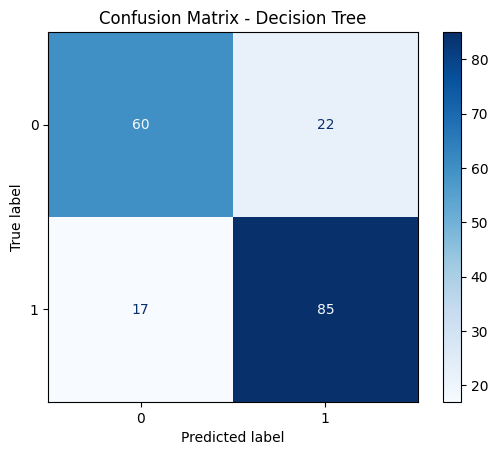

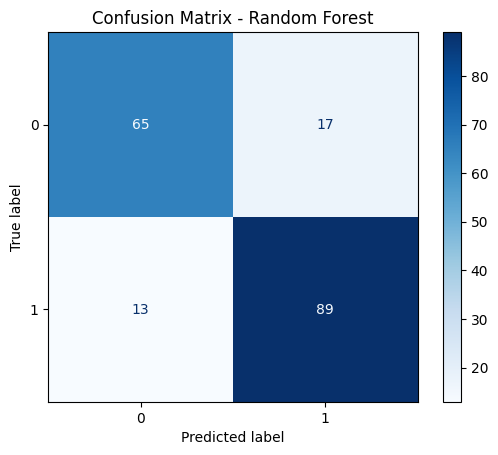

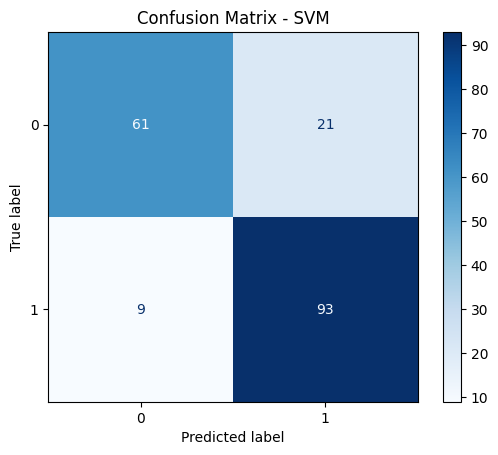

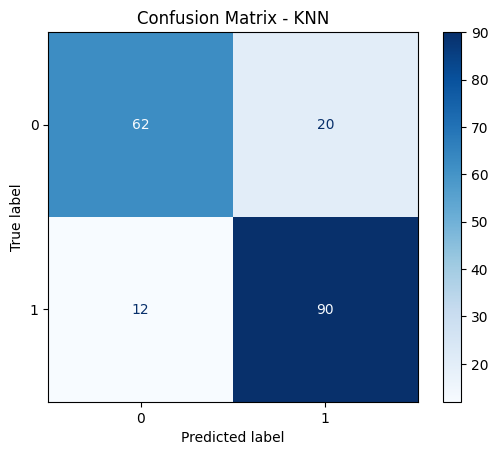

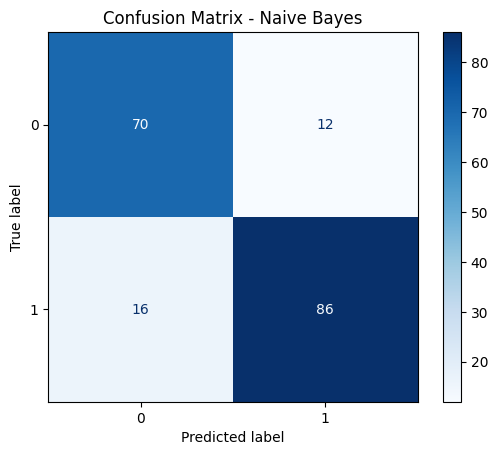

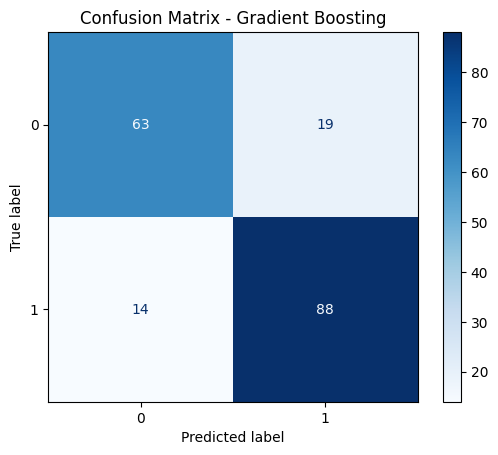

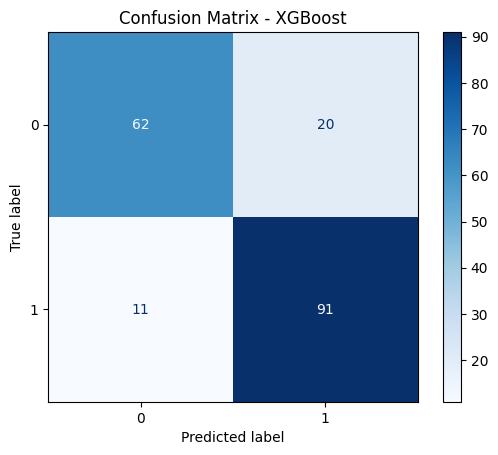

In [12]:
# ===============================
# 11. CONFUSION MATRICES FOR ALL MODELS
# ===============================
for model_name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


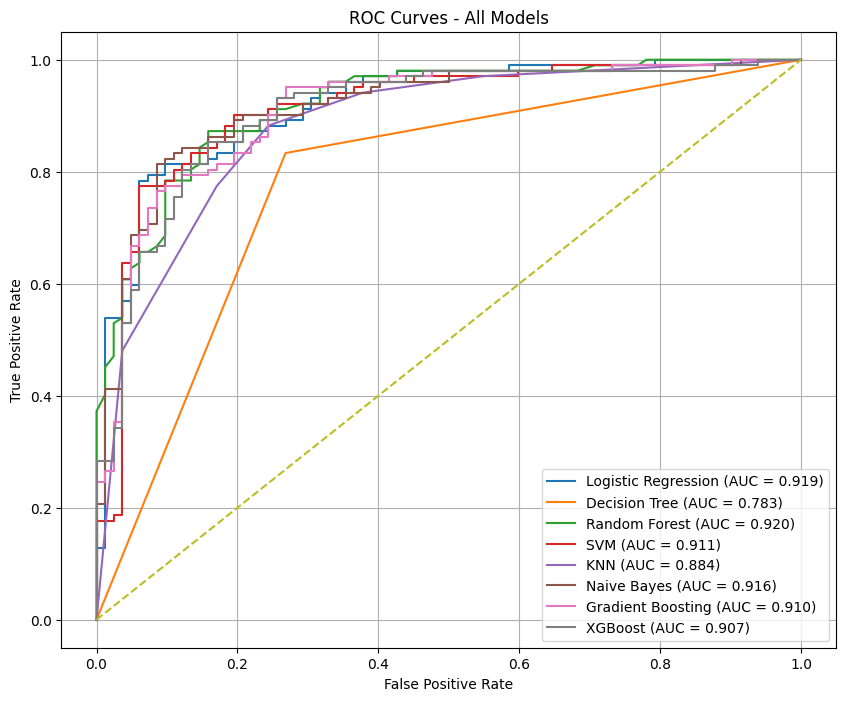

In [13]:
# ===============================
# 12. ROC CURVES FOR ALL MODELS
# ===============================
plt.figure(figsize=(10, 8))

for model_name, pipeline in trained_pipelines.items():
    if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_val)[:, 1]
    else:
        y_proba = pipeline.decision_function(X_val)

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_score = roc_auc_score(y_val, y_proba)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.grid(True)
plt.show()


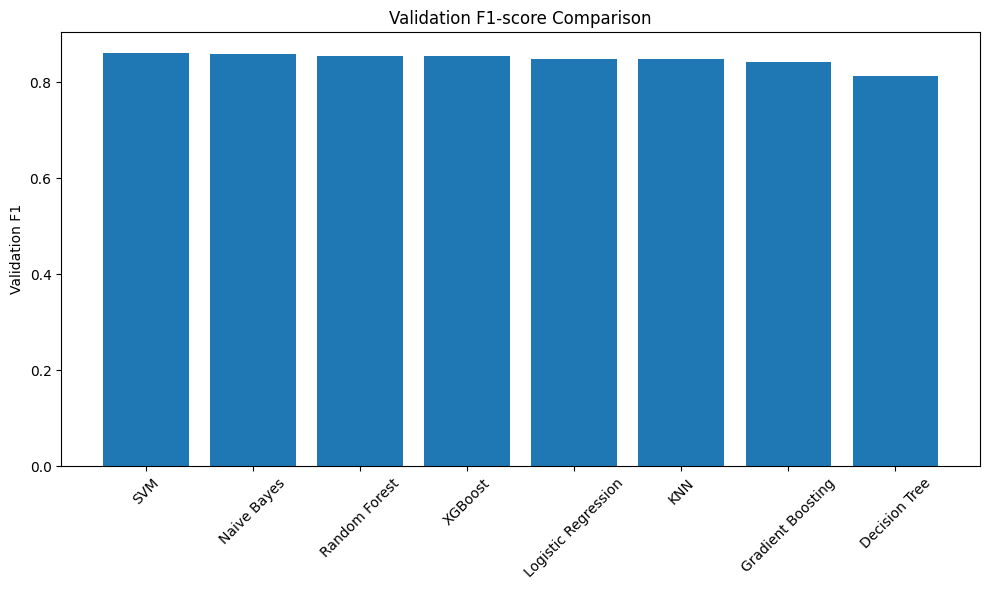

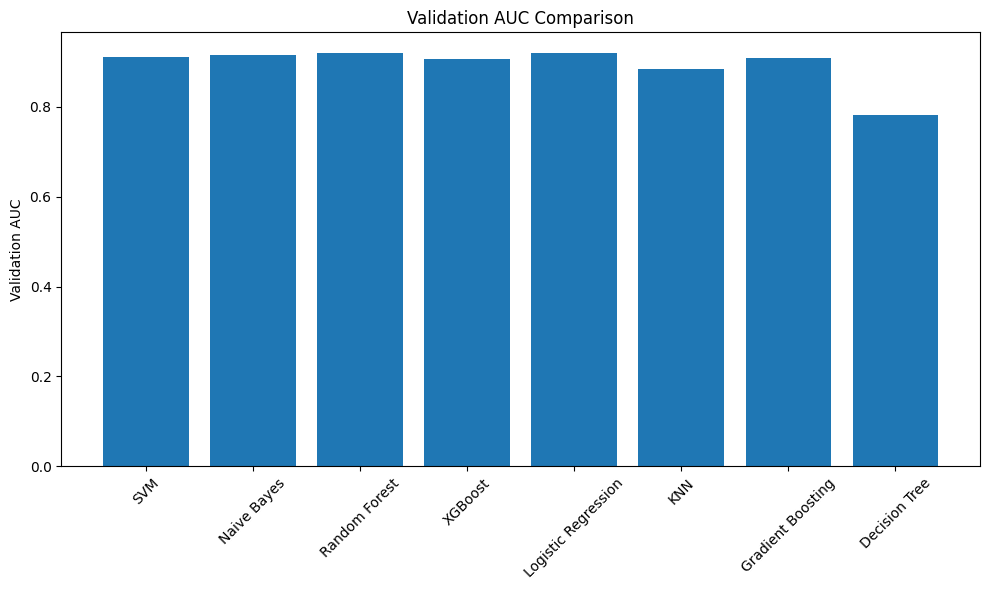

In [14]:
# ===============================
# 13. BAR CHART FOR F1 AND AUC
# ===============================
plot_df = comparison_df.sort_values(by="Validation F1", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(plot_df["Model"], plot_df["Validation F1"])
plt.xticks(rotation=45)
plt.ylabel("Validation F1")
plt.title("Validation F1-score Comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(plot_df["Model"], plot_df["Validation AUC"])
plt.xticks(rotation=45)
plt.ylabel("Validation AUC")
plt.title("Validation AUC Comparison")
plt.tight_layout()
plt.show()

In [15]:
# ===============================
# 14. AUTOMATIC TEXT FOR REPORT
# ===============================
top_models = comparison_df.sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
).head(3)

print("\n===== REPORT TEXT =====")
for i, row in top_models.iterrows():
    print(
        f"{row['Model']} was selected because it achieved "
        f"a Validation F1-score of {row['Validation F1']:.3f} "
        f"and a Validation AUC of {row['Validation AUC']:.3f}."
    )


===== REPORT TEXT =====
SVM was selected because it achieved a Validation F1-score of 0.861 and a Validation AUC of 0.911.
Naive Bayes was selected because it achieved a Validation F1-score of 0.860 and a Validation AUC of 0.916.
Random Forest was selected because it achieved a Validation F1-score of 0.856 and a Validation AUC of 0.920.


In [16]:
best_3 = comparison_df.sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
).head(3)

print(best_3[["Model", "Validation F1", "Validation AUC"]])

           Model  Validation F1  Validation AUC
0            SVM       0.861111        0.911406
4    Naive Bayes       0.860000        0.915710
3  Random Forest       0.855769        0.919895


In [17]:
# ===============================
# PHASE 4 - MODEL-CENTRIC IMPROVEMENT
# ===============================

from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.base import clone

# Dense preprocessor for Naive Bayes
preprocessor_nb = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
])

def build_pipeline(model_name, model, use_feature_selection=False, k=15):
    chosen_preprocessor = preprocessor_nb if model_name == "Naive Bayes" else preprocessor
    steps = [("preprocessor", chosen_preprocessor)]

    if use_feature_selection:
        steps.append(("feature_selection", SelectKBest(score_func=mutual_info_classif, k=k)))

    steps.append(("classifier", model))
    return Pipeline(steps=steps)

def evaluate_estimator(model_name, estimator, X_train, y_train, X_val, y_val):
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_val)

    if hasattr(estimator, "predict_proba"):
        y_scores = estimator.predict_proba(X_val)[:, 1]
    else:
        y_scores = estimator.decision_function(X_val)

    results = {
        "Model": model_name,
        "Validation Accuracy": accuracy_score(y_val, y_pred),
        "Validation Precision": precision_score(y_val, y_pred),
        "Validation Recall": recall_score(y_val, y_pred),
        "Validation F1": f1_score(y_val, y_pred),
        "Validation AUC": roc_auc_score(y_val, y_scores)
    }
    return results, y_pred, y_scores

print("Phase 3 top 3 models:")
print(best_3[["Model", "Validation F1", "Validation AUC"]])


Phase 3 top 3 models:
           Model  Validation F1  Validation AUC
0            SVM       0.861111        0.911406
4    Naive Bayes       0.860000        0.915710
3  Random Forest       0.855769        0.919895


In [18]:
# ===============================
# 15.1 HYPERPARAMETER TUNING ON THE BEST MODELS
# ===============================

tuning_configs = {
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "param_grid": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"],
            "classifier__gamma": ["scale", "auto"]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "param_grid": {
            "classifier__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "param_grid": {
            "classifier__n_estimators": [200, 300],
            "classifier__max_depth": [None, 10, 20],
            "classifier__min_samples_split": [2, 5],
            "classifier__min_samples_leaf": [1, 2]
        }
    }
}

tuned_models = {}
tuning_results = []

for model_name, config in tuning_configs.items():
    print(f"Running GridSearchCV for {model_name}...")

    pipeline = build_pipeline(model_name, config["model"])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["param_grid"],
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        refit="f1",
        cv=5,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    tuned_models[model_name] = search.best_estimator_

    val_result, _, _ = evaluate_estimator(
        model_name,
        clone(search.best_estimator_),
        X_train,
        y_train,
        X_val,
        y_val
    )

    tuning_results.append({
        "Model": model_name,
        "Best Params": search.best_params_,
        "CV Best F1": search.best_score_,
        "Validation Accuracy": val_result["Validation Accuracy"],
        "Validation Precision": val_result["Validation Precision"],
        "Validation Recall": val_result["Validation Recall"],
        "Validation F1": val_result["Validation F1"],
        "Validation AUC": val_result["Validation AUC"]
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
)

print("\n===== PHASE 4 TUNING RESULTS =====")
print(tuning_results_df[[
    "Model", "CV Best F1", "Validation Accuracy",
    "Validation Precision", "Validation Recall",
    "Validation F1", "Validation AUC"
]])

print("\n===== BEST PARAMETERS =====")
for _, row in tuning_results_df.iterrows():
    print(f"\n{row['Model']}:")
    print(row["Best Params"])


Running GridSearchCV for SVM...
Running GridSearchCV for Naive Bayes...
Running GridSearchCV for Random Forest...

===== PHASE 4 TUNING RESULTS =====
           Model  CV Best F1  Validation Accuracy  Validation Precision  \
2  Random Forest    0.838711             0.842391              0.841121   
0            SVM    0.843500             0.836957              0.815789   
1    Naive Bayes    0.820667             0.847826              0.877551   

   Validation Recall  Validation F1  Validation AUC  
2           0.882353       0.861244        0.926231  
0           0.911765       0.861111        0.911406  
1           0.843137       0.860000        0.915710  

===== BEST PARAMETERS =====

Random Forest:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

SVM:
{'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

Naive Bayes:
{'classifier__var_smoothing': 1e-09}


In [19]:
# ===============================
# 15.2 HANDLE CLASS IMBALANCE (IF APPLICABLE)
# ===============================

class_distribution = y_train.value_counts(normalize=True) * 100
print("Training class distribution (%):")
print(class_distribution)

print("\nBecause the class split is not extremely imbalanced,")
print("I will compare class_weight='balanced' and threshold tuning instead of forcing SMOTE.")

best_svm = tuned_models["SVM"].named_steps["classifier"]
best_rf = tuned_models["Random Forest"].named_steps["classifier"]

balanced_candidates = {
    "SVM Balanced": build_pipeline(
        "SVM",
        SVC(
            C=best_svm.C,
            kernel=best_svm.kernel,
            gamma=best_svm.gamma,
            probability=True,
            class_weight="balanced",
            random_state=42
        )
    ),
    "Random Forest Balanced": build_pipeline(
        "Random Forest",
        RandomForestClassifier(
            n_estimators=best_rf.n_estimators,
            max_depth=best_rf.max_depth,
            min_samples_split=best_rf.min_samples_split,
            min_samples_leaf=best_rf.min_samples_leaf,
            class_weight="balanced",
            random_state=42
        )
    )
}

imbalance_results = []
imbalance_fitted_models = {}

for model_name, estimator in balanced_candidates.items():
    result, _, _ = evaluate_estimator(
        model_name, estimator, X_train, y_train, X_val, y_val
    )
    imbalance_results.append(result)
    imbalance_fitted_models[model_name] = estimator

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
)

print("\n===== CLASS IMBALANCE RESULTS =====")
print(imbalance_results_df)

# Threshold tuning on the tuned model with the best validation AUC
threshold_model_name = tuning_results_df.sort_values(
    by=["Validation AUC", "Validation F1"], ascending=False
).iloc[0]["Model"]

threshold_model = clone(tuned_models[threshold_model_name])
threshold_model.fit(X_train, y_train)

if hasattr(threshold_model, "predict_proba"):
    threshold_scores = threshold_model.predict_proba(X_val)[:, 1]
else:
    threshold_scores = threshold_model.decision_function(X_val)

threshold_rows = []

for threshold in np.arange(0.30, 0.71, 0.05):
    y_pred_threshold = (threshold_scores >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": round(threshold, 2),
        "Validation Precision": precision_score(y_val, y_pred_threshold),
        "Validation Recall": recall_score(y_val, y_pred_threshold),
        "Validation F1": f1_score(y_val, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    by=["Validation F1", "Validation Precision"], ascending=False
)

best_threshold = threshold_df.iloc[0]["Threshold"]
best_threshold_f1 = threshold_df.iloc[0]["Validation F1"]

print(f"\nThreshold tuning model: {threshold_model_name}")
print(threshold_df)
print(f"\nBest threshold = {best_threshold:.2f} with Validation F1 = {best_threshold_f1:.3f}")

threshold_tuned_result = pd.DataFrame([{
    "Model": f"{threshold_model_name} (threshold={best_threshold:.2f})",
    "Validation Accuracy": accuracy_score(y_val, (threshold_scores >= best_threshold).astype(int)),
    "Validation Precision": precision_score(y_val, (threshold_scores >= best_threshold).astype(int)),
    "Validation Recall": recall_score(y_val, (threshold_scores >= best_threshold).astype(int)),
    "Validation F1": f1_score(y_val, (threshold_scores >= best_threshold).astype(int)),
    "Validation AUC": roc_auc_score(y_val, threshold_scores)
}])

print("\n===== THRESHOLD-TUNED RESULT =====")
print(threshold_tuned_result)


Training class distribution (%):
target
1    55.298913
0    44.701087
Name: proportion, dtype: float64

Because the class split is not extremely imbalanced,
I will compare class_weight='balanced' and threshold tuning instead of forcing SMOTE.

===== CLASS IMBALANCE RESULTS =====
                    Model  Validation Accuracy  Validation Precision  \
0            SVM Balanced             0.836957              0.833333   
1  Random Forest Balanced             0.836957              0.839623   

   Validation Recall  Validation F1  Validation AUC  
0           0.882353       0.857143        0.910808  
1           0.872549       0.855769        0.924558  

Threshold tuning model: Random Forest
   Threshold  Validation Precision  Validation Recall  Validation F1
0       0.30              0.775194           0.980392       0.865801
4       0.50              0.841121           0.882353       0.861244
1       0.35              0.777778           0.960784       0.859649
2       0.40              

In [20]:
# ===============================
# 15.3 FEATURE SELECTION / ENGINEERING
# ===============================

feature_selection_results = []
feature_selected_models = {}

feature_selection_candidates = {
    "SVM": clone(tuned_models["SVM"].named_steps["classifier"]),
    "Random Forest": clone(tuned_models["Random Forest"].named_steps["classifier"])
}

k_values = [10, 15, 20, "all"]

for model_name, clf in feature_selection_candidates.items():
    for k in k_values:
        use_fs = k != "all"

        estimator = build_pipeline(
            model_name,
            clone(clf),
            use_feature_selection=use_fs,
            k=k if use_fs else 15
        )

        result, _, _ = evaluate_estimator(
            f"{model_name} + SelectKBest(k={k})",
            estimator,
            X_train,
            y_train,
            X_val,
            y_val
        )

        result["Base Model"] = model_name
        result["k"] = k
        feature_selection_results.append(result)
        feature_selected_models[f"{model_name}_k_{k}"] = estimator

feature_selection_results_df = pd.DataFrame(feature_selection_results).sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
)

print("===== FEATURE SELECTION RESULTS =====")
print(feature_selection_results_df)

best_fs_row = feature_selection_results_df.iloc[0]
best_fs_key = f"{best_fs_row['Base Model']}_k_{best_fs_row['k']}"
best_fs_model = feature_selected_models[best_fs_key]

print("\nBest feature selection model:")
print(best_fs_row[[
    "Model", "Validation Accuracy", "Validation Precision",
    "Validation Recall", "Validation F1", "Validation AUC"
]])

# Show selected feature names if SelectKBest was used
best_fs_model.fit(X_train, y_train)

if "feature_selection" in best_fs_model.named_steps:
    feature_names = best_fs_model.named_steps["preprocessor"].get_feature_names_out()
    selected_mask = best_fs_model.named_steps["feature_selection"].get_support()
    selected_features = feature_names[selected_mask]

    print("\nSelected features:")
    print(selected_features.tolist())
else:
    print("\nBest result happened when keeping all features.")


===== FEATURE SELECTION RESULTS =====
                                Model  Validation Accuracy  \
7  Random Forest + SelectKBest(k=all)             0.842391   
3            SVM + SelectKBest(k=all)             0.836957   
1             SVM + SelectKBest(k=15)             0.836957   
6   Random Forest + SelectKBest(k=20)             0.831522   
5   Random Forest + SelectKBest(k=15)             0.831522   
2             SVM + SelectKBest(k=20)             0.826087   
4   Random Forest + SelectKBest(k=10)             0.820652   
0             SVM + SelectKBest(k=10)             0.815217   

   Validation Precision  Validation Recall  Validation F1  Validation AUC  \
7              0.841121           0.882353       0.861244        0.926231   
3              0.815789           0.911765       0.861111        0.911406   
1              0.821429           0.901961       0.859813        0.898254   
6              0.814159           0.901961       0.855814        0.927427   
5              0.8

In [21]:
# ===============================
# 15.4 BUILD FINAL ENSEMBLE
# ===============================

best_single_model_name = tuning_results_df.iloc[0]["Model"]
best_single_model = clone(tuned_models[best_single_model_name])

voting_ensemble = VotingClassifier(
    estimators=[
        ("svm", clone(tuned_models["SVM"])),
        ("nb", clone(tuned_models["Naive Bayes"])),
        ("rf", clone(tuned_models["Random Forest"]))
    ],
    voting="soft"
)

stacking_ensemble = StackingClassifier(
    estimators=[
        ("svm", clone(tuned_models["SVM"])),
        ("nb", clone(tuned_models["Naive Bayes"])),
        ("rf", clone(tuned_models["Random Forest"]))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1
)

final_candidates = {
    f"Best Single Model ({best_single_model_name})": best_single_model,
    "Soft Voting Ensemble": voting_ensemble,
    "Stacking Ensemble": stacking_ensemble,
    "Best Feature Selection Model": clone(best_fs_model)
}

final_results = []
final_fitted_models = {}

for model_name, estimator in final_candidates.items():
    result, _, _ = evaluate_estimator(
        model_name, estimator, X_train, y_train, X_val, y_val
    )
    final_results.append(result)
    final_fitted_models[model_name] = estimator

final_results_df = pd.DataFrame(final_results).sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
)

print("===== FINAL PHASE 4 COMPARISON =====")
print(final_results_df)


===== FINAL PHASE 4 COMPARISON =====
                               Model  Validation Accuracy  \
1               Soft Voting Ensemble             0.858696   
0  Best Single Model (Random Forest)             0.842391   
3       Best Feature Selection Model             0.842391   
2                  Stacking Ensemble             0.836957   

   Validation Precision  Validation Recall  Validation F1  Validation AUC  
1              0.872549           0.872549       0.872549        0.928144  
0              0.841121           0.882353       0.861244        0.926231  
3              0.841121           0.882353       0.861244        0.926231  
2              0.833333           0.882353       0.857143        0.923960  


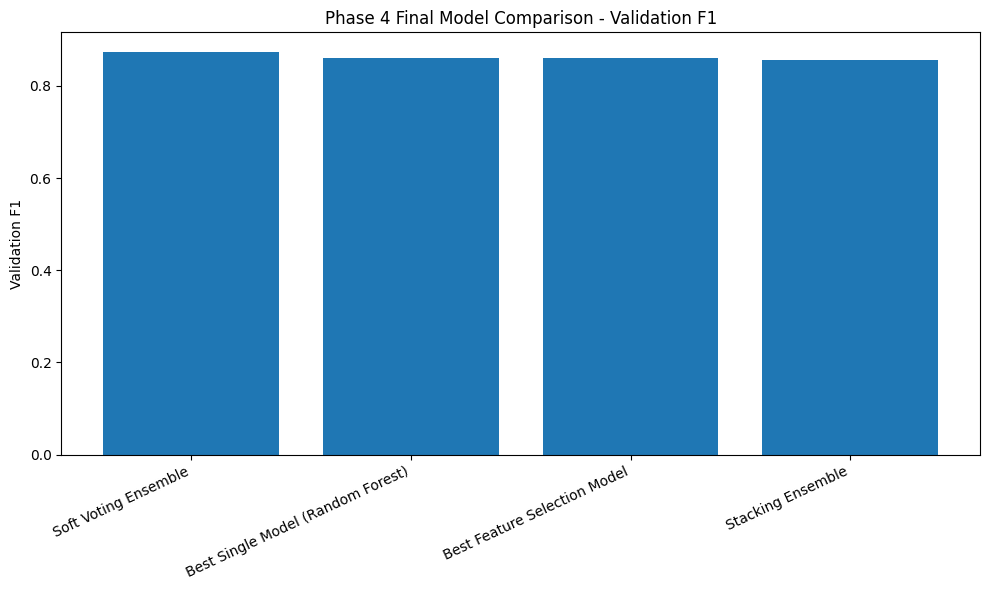

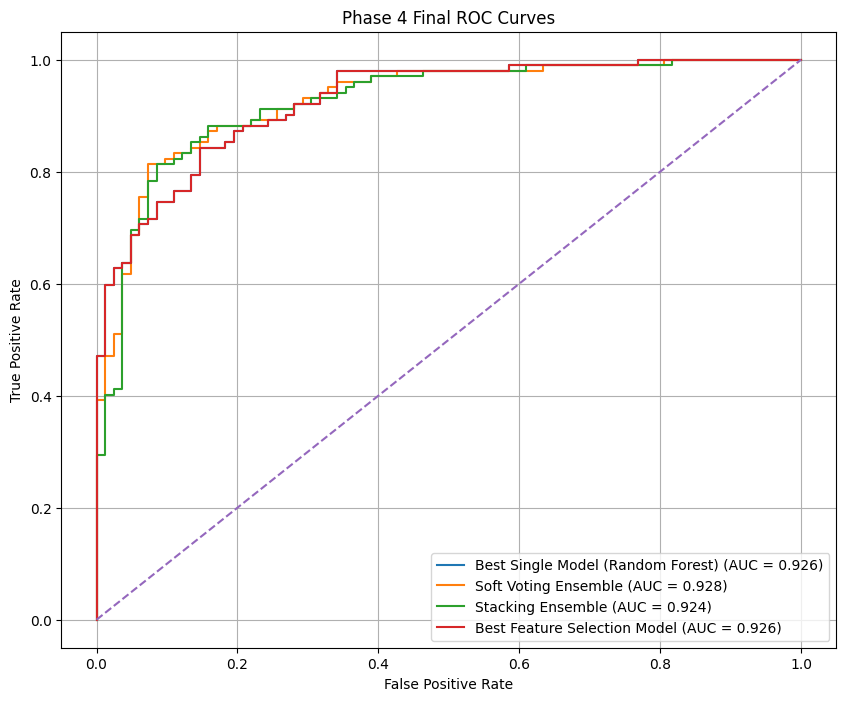

In [22]:
# ===============================
# 15.5 FINAL PHASE 4 PLOTS
# ===============================

plt.figure(figsize=(10, 6))
plot_df = final_results_df.sort_values(by="Validation F1", ascending=False)

plt.bar(plot_df["Model"], plot_df["Validation F1"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Validation F1")
plt.title("Phase 4 Final Model Comparison - Validation F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

for model_name, estimator in final_fitted_models.items():
    if hasattr(estimator, "predict_proba"):
        y_scores = estimator.predict_proba(X_val)[:, 1]
    else:
        y_scores = estimator.decision_function(X_val)

    fpr, tpr, _ = roc_curve(y_val, y_scores)
    auc_score = roc_auc_score(y_val, y_scores)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Phase 4 Final ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# ===============================
# 15.6 AUTOMATIC TEXT FOR THE REPORT
# ===============================

phase4_winner = final_results_df.iloc[0]

print("===== PHASE 4 REPORT TEXT =====")
print(
    f"The best final model in Phase 4 was {phase4_winner['Model']}. "
    f"It achieved a Validation F1-score of {phase4_winner['Validation F1']:.3f} "
    f"and a Validation AUC of {phase4_winner['Validation AUC']:.3f}."
)

print("\nHyperparameter tuning was applied to the three best models from Phase 3: SVM, Naive Bayes, and Random Forest.")
print("Class imbalance handling was checked using class_weight='balanced' and threshold tuning.")
print("Feature selection was tested using SelectKBest to see whether removing weaker features improves performance.")
print("Finally, soft voting and stacking ensembles were built and compared against the best single tuned model.")


===== PHASE 4 REPORT TEXT =====
The best final model in Phase 4 was Soft Voting Ensemble. It achieved a Validation F1-score of 0.873 and a Validation AUC of 0.928.

Hyperparameter tuning was applied to the three best models from Phase 3: SVM, Naive Bayes, and Random Forest.
Class imbalance handling was checked using class_weight='balanced' and threshold tuning.
Feature selection was tested using SelectKBest to see whether removing weaker features improves performance.
Finally, soft voting and stacking ensembles were built and compared against the best single tuned model.


In [31]:
# ===============================
# IMPROVED SVM TUNING
# ===============================

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

svm_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 50, 100],
    "classifier__kernel": ["linear", "rbf", "poly"],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "classifier__degree": [2, 3]   # only matters for poly
}

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

best_svm = svm_search.best_estimator_

print("Best SVM Parameters:")
print(svm_search.best_params_)

y_val_pred_svm = best_svm.predict(X_val)
y_val_proba_svm = best_svm.predict_proba(X_val)[:, 1]

print("\nImproved SVM Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("Precision:", precision_score(y_val, y_val_pred_svm))
print("Recall:", recall_score(y_val, y_val_pred_svm))
print("F1:", f1_score(y_val, y_val_pred_svm))
print("AUC:", roc_auc_score(y_val, y_val_proba_svm))

Best SVM Parameters:
{'classifier__C': 0.01, 'classifier__degree': 2, 'classifier__gamma': 1, 'classifier__kernel': 'poly'}

Improved SVM Validation Results:
Accuracy: 0.8260869565217391
Precision: 0.8070175438596491
Recall: 0.9019607843137255
F1: 0.8518518518518519
AUC: 0.8713534194165472


In [32]:
# ===============================
# IMPROVED RANDOM FOREST TUNING
# ===============================

from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None]
}

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best RF Parameters:")
print(rf_search.best_params_)

y_val_pred_rf = best_rf.predict(X_val)
y_val_proba_rf = best_rf.predict_proba(X_val)[:, 1]

print("\nImproved RF Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall:", recall_score(y_val, y_val_pred_rf))
print("F1:", f1_score(y_val, y_val_pred_rf))
print("AUC:", roc_auc_score(y_val, y_val_proba_rf))

Best RF Parameters:
{'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Improved RF Validation Results:
Accuracy: 0.8478260869565217
Precision: 0.8135593220338984
Recall: 0.9411764705882353
F1: 0.8727272727272727
AUC: 0.9215686274509804


In [33]:
tuned_models = {
    "SVM": best_svm,
    "Random Forest": best_rf,
    "Naive Bayes": tuned_models["Naive Bayes"] if "Naive Bayes" in tuned_models else trained_pipelines["Naive Bayes"]
}

In [34]:
# ===============================
# FINAL EVALUATION ON TEST SET
# ===============================

final_results = []

# Assume:
# - tuned_models = your tuned models
# - trained_pipelines = baseline models
# - voting_ensemble = your final ensemble

top3_names = best_3['Model'].tolist()

for name in top3_names:

    # ---------- BASELINE ----------
    baseline_model = trained_pipelines[name]
    y_pred_base = baseline_model.predict(X_test)

    if hasattr(baseline_model, "predict_proba"):
        y_proba_base = baseline_model.predict_proba(X_test)[:,1]
        auc_base = roc_auc_score(y_test, y_proba_base)
    else:
        auc_base = np.nan

    final_results.append({
        "Model": name,
        "Type": "Baseline",
        "Accuracy": accuracy_score(y_test, y_pred_base),
        "Precision": precision_score(y_test, y_pred_base),
        "Recall": recall_score(y_test, y_pred_base),
        "F1": f1_score(y_test, y_pred_base),
        "AUC": auc_base
    })

    # ---------- TUNED ----------
    if name in tuned_models:
        tuned_model = tuned_models[name]
        y_pred_tuned = tuned_model.predict(X_test)

        if hasattr(tuned_model, "predict_proba"):
            y_proba_tuned = tuned_model.predict_proba(X_test)[:,1]
            auc_tuned = roc_auc_score(y_test, y_proba_tuned)
        else:
            auc_tuned = np.nan

        final_results.append({
            "Model": name,
            "Type": "Tuned",
            "Accuracy": accuracy_score(y_test, y_pred_tuned),
            "Precision": precision_score(y_test, y_pred_tuned),
            "Recall": recall_score(y_test, y_pred_tuned),
            "F1": f1_score(y_test, y_pred_tuned),
            "AUC": auc_tuned
        })

# ---------- ENSEMBLE ----------
y_pred_ens = voting_ensemble.predict(X_test)
y_proba_ens = voting_ensemble.predict_proba(X_test)[:,1]

final_results.append({
    "Model": "Ensemble",
    "Type": "Final",
    "Accuracy": accuracy_score(y_test, y_pred_ens),
    "Precision": precision_score(y_test, y_pred_ens),
    "Recall": recall_score(y_test, y_pred_ens),
    "F1": f1_score(y_test, y_pred_ens),
    "AUC": roc_auc_score(y_test, y_proba_ens)
})

final_results_df = pd.DataFrame(final_results)

display(final_results_df)

,Model,Type,Accuracy,Precision,Recall,F1,AUC
0,SVM,Baseline,0.847826,0.836364,0.901961,0.867925,0.937351
1,SVM,Tuned,0.869565,0.854545,0.921569,0.886792,0.955524
2,Naive Bayes,Baseline,0.815217,0.854167,0.803922,0.828283,0.927786
3,Naive Bayes,Tuned,0.815217,0.854167,0.803922,0.828283,0.927786
4,Random Forest,Baseline,0.826087,0.872340,0.803922,0.836735,0.930177
5,Random Forest,Tuned,0.836957,0.875000,0.823529,0.848485,0.934959
6,Ensemble,Final,0.836957,0.860000,0.843137,0.851485,0.940698


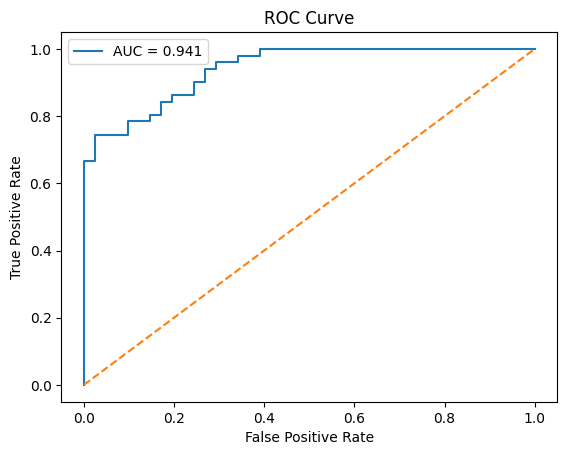

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Example (use your best model)
y_proba = voting_ensemble.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

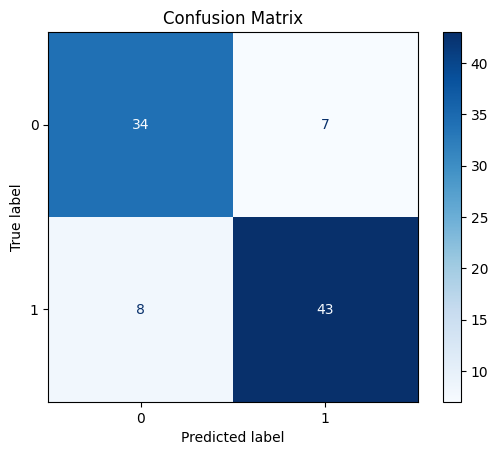

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_ens)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()